<a href="https://colab.research.google.com/github/SANTHIYAM306/mlops_training_tasks/blob/main/task15_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the digits dataset
digits = load_digits()
X = digits.data
y = digits.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Define the parameter grid for K
param_grid = {'n_neighbors': range(1, 21)} # Test K from 1 to 20

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Initialize GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best K and its corresponding score
best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

print(f"Best K: {best_k}")
print(f"Best Cross-Validation Score: {best_score:.4f}")

# Train the KNN classifier with the best K
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_knn.predict(X_test)

# Evaluate the model on the test set
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with Best K: {test_accuracy:.4f}")

Best K: 1
Best Cross-Validation Score: 0.9861
Test Accuracy with Best K: 0.9778


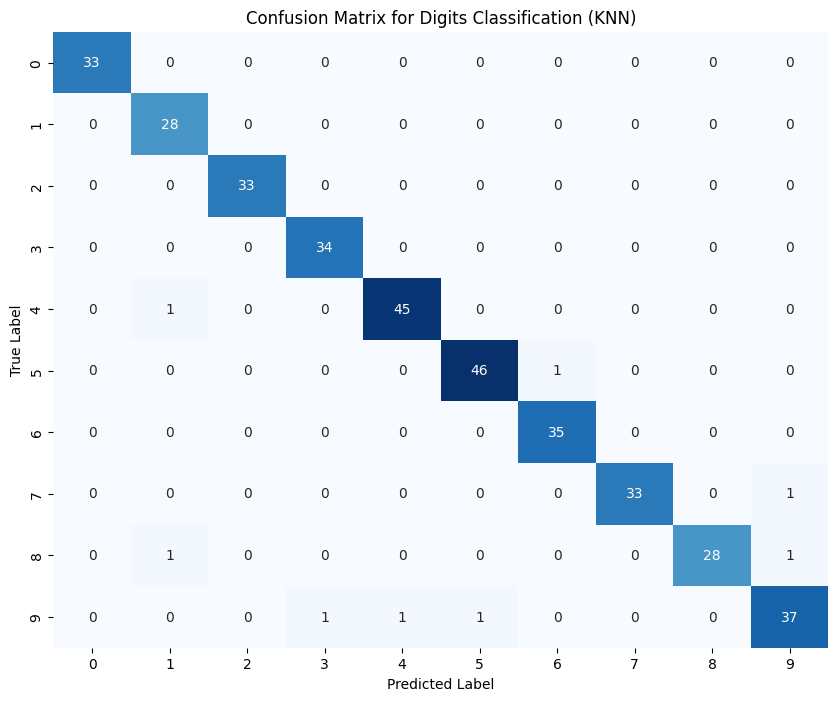

In [8]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Digits Classification (KNN)')
plt.show()

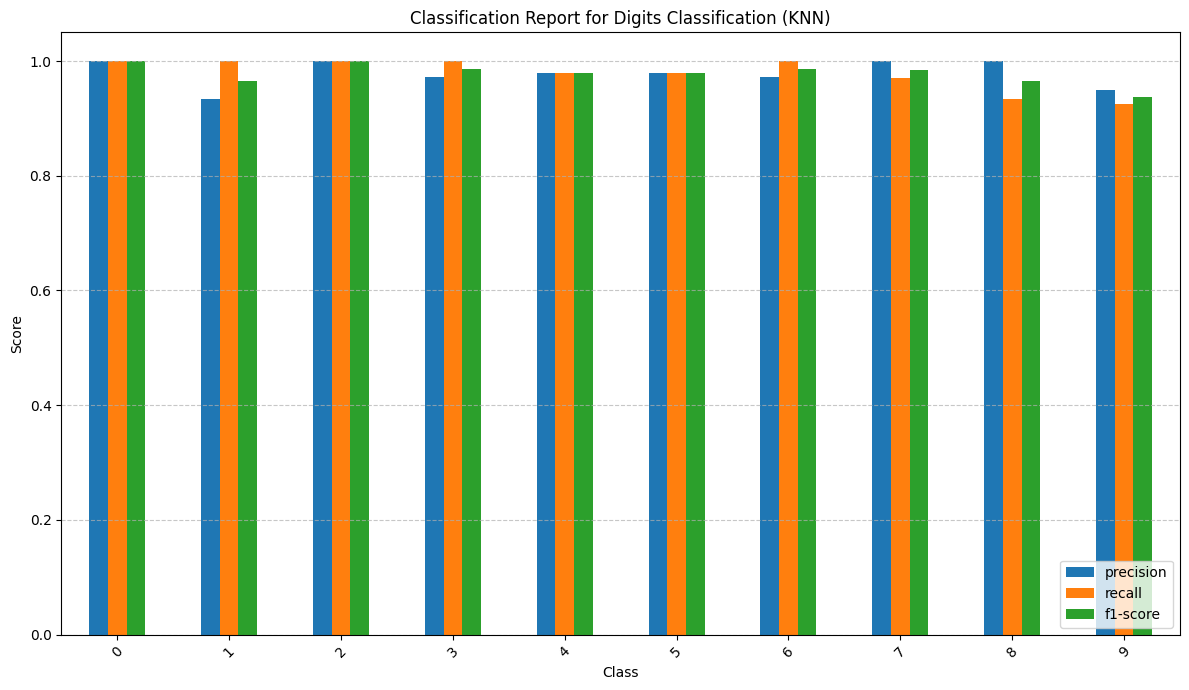


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      0.98      0.98        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.93      0.97        30
           9       0.95      0.93      0.94        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [10]:
# Generate the classification report
import pandas as pd
report = classification_report(y_test, y_pred, target_names=[str(i) for i in digits.target_names], output_dict=True)

# Convert to DataFrame for easier plotting
report_df = pd.DataFrame(report).transpose()

# Plot the classification report (excluding 'accuracy', 'macro avg', 'weighted avg' for bar plot)
report_df_plot = report_df.iloc[:-3, :-1] # Exclude accuracy, macro avg, weighted avg and support column

report_df_plot.plot(kind='bar', figsize=(12, 7))
plt.title('Classification Report for Digits Classification (KNN)')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the full classification report as text for detailed view
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in digits.target_names]))